## 1. Know The Data


## Import Libraries

In [1]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing  tools for visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Import preprocessing libraries
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# Import Model
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
import xgboost as xgb

# Import evaluation metric libraries
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Import tree for visualization
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import SVG,display
from graphviz import Source

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Dataset Loading

In [3]:
# Load Dataset
df = pd.read_csv("usedCars.csv")

In [4]:
# Dataset First Look
# View top 5 rows of the dataset
df.head()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


## Dataset Rows & Columns count

In [5]:
df.shape

(1064, 19)

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


## Duplicate Values

In [7]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

number of duplicated rows are 0


## Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()

Id                     0
Company                0
Model                  0
Variant                0
FuelType               1
Colour                 0
Kilometer              0
BodyStyle              0
TransmissionType     714
ManufactureDate        0
ModelYear              0
CngKit              1042
Price                  0
Owner                  0
DealerState            0
DealerName             0
City                   0
Warranty               0
QualityScore           0
dtype: int64

In [9]:
# Impute missing values in 'TransmissionType' with the mode
mode_value = df['TransmissionType'].mode()[0]
df['TransmissionType'].fillna(mode_value, inplace=True)
# Calculate the mode of the 'CngKit' column
cngkit_mode = df['CngKit'].mode()[0]

# Fill missing values in 'CngKit' with the mode
df['CngKit'].fillna(cngkit_mode, inplace=True)

## Understanding The Variables
     

In [10]:
# Dataset Columns
df.columns

Index(['Id', 'Company', 'Model', 'Variant', 'FuelType', 'Colour', 'Kilometer',
       'BodyStyle', 'TransmissionType', 'ManufactureDate', 'ModelYear',
       'CngKit', 'Price', 'Owner', 'DealerState', 'DealerName', 'City',
       'Warranty', 'QualityScore'],
      dtype='object')

## Feature Engineering & Data Pre-processing

In [11]:
df['Price'] = df['Price'].replace({r'[^\d.]': ''}, regex=True)  # Remove commas and non-numeric characters
df['Price'] = df['Price'].astype(float)  # Convert to float


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Company'] = le.fit_transform(df['Company'])


In [13]:
df['FuelType'] = le.fit_transform(df['FuelType'])


In [14]:
df['TransmissionType'] = le.fit_transform(df['TransmissionType'])


In [15]:
df['Owner'] = le.fit_transform(df['Owner'])


In [16]:
df = pd.get_dummies(df, columns=['City', 'DealerState', 'DealerName'], drop_first=True)


In [17]:
import pandas as pd
from datetime import datetime

In [18]:
# Replace 'your_data.csv' with the path to your CSV file
df = pd.read_csv('usedCars.csv')

In [19]:
df['ManufactureDate'] = pd.to_datetime(df['ManufactureDate'])

In [20]:
df['ManufactureDate'] = pd.to_datetime(df['ManufactureDate'], format='%Y-%m-%d')

In [21]:
today = pd.Timestamp(datetime.now().date())
df['CarAge'] = (today - df['ManufactureDate']).dt.days // 365


In [22]:
current_year = datetime.now().year
df['CarAgeFromModelYear'] = current_year - df['ModelYear']


In [23]:
df[['ManufactureDate', 'ModelYear', 'CarAge', 'CarAgeFromModelYear']].head()


,ManufactureDate,ModelYear,CarAge,CarAgeFromModelYear
0,2018-02-01,2018,6,7
1,2021-03-01,2021,3,4
2,2015-03-01,2015,9,10
3,2020-08-01,2020,4,5
4,2010-11-01,2010,14,15


In [24]:
# New updated DataFrame
df.head()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,...,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore,CarAge,CarAgeFromModelYear
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,...,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8,6,7
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,...,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3,3,4
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,...,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9,9,10
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,...,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1,4,5
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,...,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5,14,15


In [25]:
#statistical view of the numerical data
df.describe()

,Id,Kilometer,ManufactureDate,ModelYear,Warranty,QualityScore,CarAge,CarAgeFromModelYear
count,1064.000000,1064.000000,1064,1064.000000,1064.000000,1064.000000,1064.000000,1064.000000
mean,568156.542293,52807.187970,2017-04-11 14:09:55.488721920,2016.864662,0.738722,7.770207,7.274436,8.135338
min,525978.000000,101.000000,2003-11-01 00:00:00,2003.000000,0.000000,0.000000,1.000000,2.000000
25%,555321.500000,32113.500000,2015-08-01 00:00:00,2015.000000,0.000000,7.500000,5.000000,6.000000
50%,572753.000000,49432.000000,2017-07-01 00:00:00,2017.000000,1.000000,7.800000,7.000000,8.000000
75%,583072.750000,68828.500000,2019-04-01 00:00:00,2019.000000,1.000000,8.100000,9.000000,10.000000
max,589122.000000,640000.000000,2023-07-01 00:00:00,2023.000000,1.000000,9.400000,21.000000,22.000000
std,16438.139974,33840.296979,NaN,2.996786,0.439538,0.719717,3.008903,2.996786


## Check Unique Values for each variable

In [26]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in Id is 1064
No. of unique values in Company is 23
No. of unique values in Model is 218
No. of unique values in Variant is 575
No. of unique values in FuelType is 5
No. of unique values in Colour is 76
No. of unique values in Kilometer is 1006
No. of unique values in BodyStyle is 10
No. of unique values in TransmissionType is 9
No. of unique values in ManufactureDate is 162
No. of unique values in ModelYear is 17
No. of unique values in CngKit is 2
No. of unique values in Price is 367
No. of unique values in Owner is 4
No. of unique values in DealerState is 10
No. of unique values in DealerName is 57
No. of unique values in City is 11
No. of unique values in Warranty is 2
No. of unique values in QualityScore is 43
No. of unique values in CarAge is 18
No. of unique values in CarAgeFromModelYear is 17


In [27]:
# Defining dependent variable
dependent_variable = ['Selling_Price']

## Data Vizualization

## Chart - 1 : Top 10 Most Selling Car

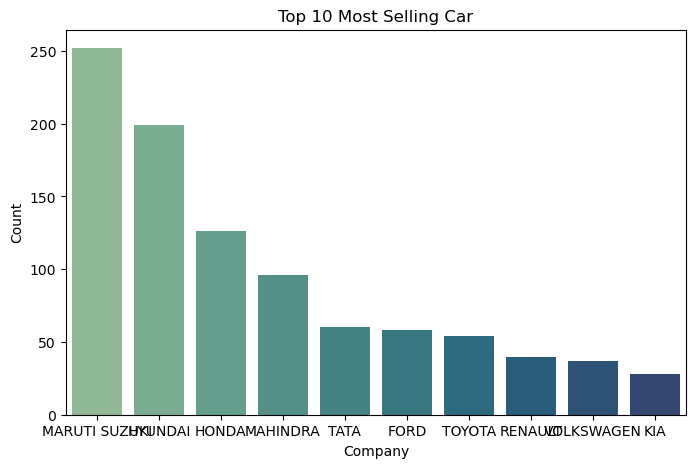

In [28]:
# Chart - 1 Count plot visualization code for top 10 most selling car
# Count the occurrences of each unique car name in the 'Car_Name' column and take the top 10 most selling car
top10 = df['Company'].value_counts()[:10]

# Create a count plot to visualize the top 10 car
plt.figure(figsize=(8, 5))
sns.countplot(x='Company', data=df, order=top10.index, palette='crest')

# Set labels and title for the plot
plt.xlabel('Company')
plt.ylabel('Count')
plt.title('Top 10 Most Selling Car')

# Display the plot
plt.show()
     

## Chart - 2 : Number of Cars Bought Each Year

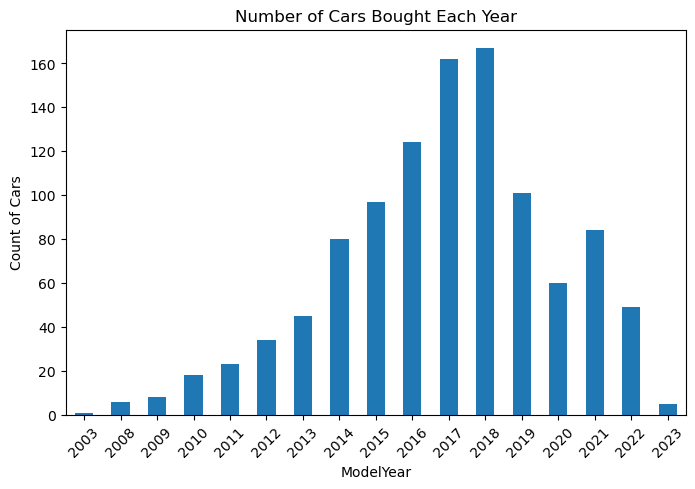

In [29]:
# Chart - 2 Bar plot visualization code for Number of Cars Bought Each Year
# Set the figure size for the plot
plt.figure(figsize=(8, 5))

# Group the data by the 'Year' column and count the number of occurrences for each year
yearly_counts = df.groupby('ModelYear').count()['Company']

# Create a bar plot to visualize the count of cars bought in each year
yearly_counts.plot(kind='bar')

# Rotate the x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Set labels and title for the plot
plt.xlabel('ModelYear')
plt.ylabel('Count of Cars')
plt.title('Number of Cars Bought Each Year')

# Display the plot
plt.show()

From the above chart, we got to know that 2018 has the highest count of car purchases (popular year for buying cars), followed by 2017 and 2016.

## Chart - 3 : Distribution of Categorical Variable

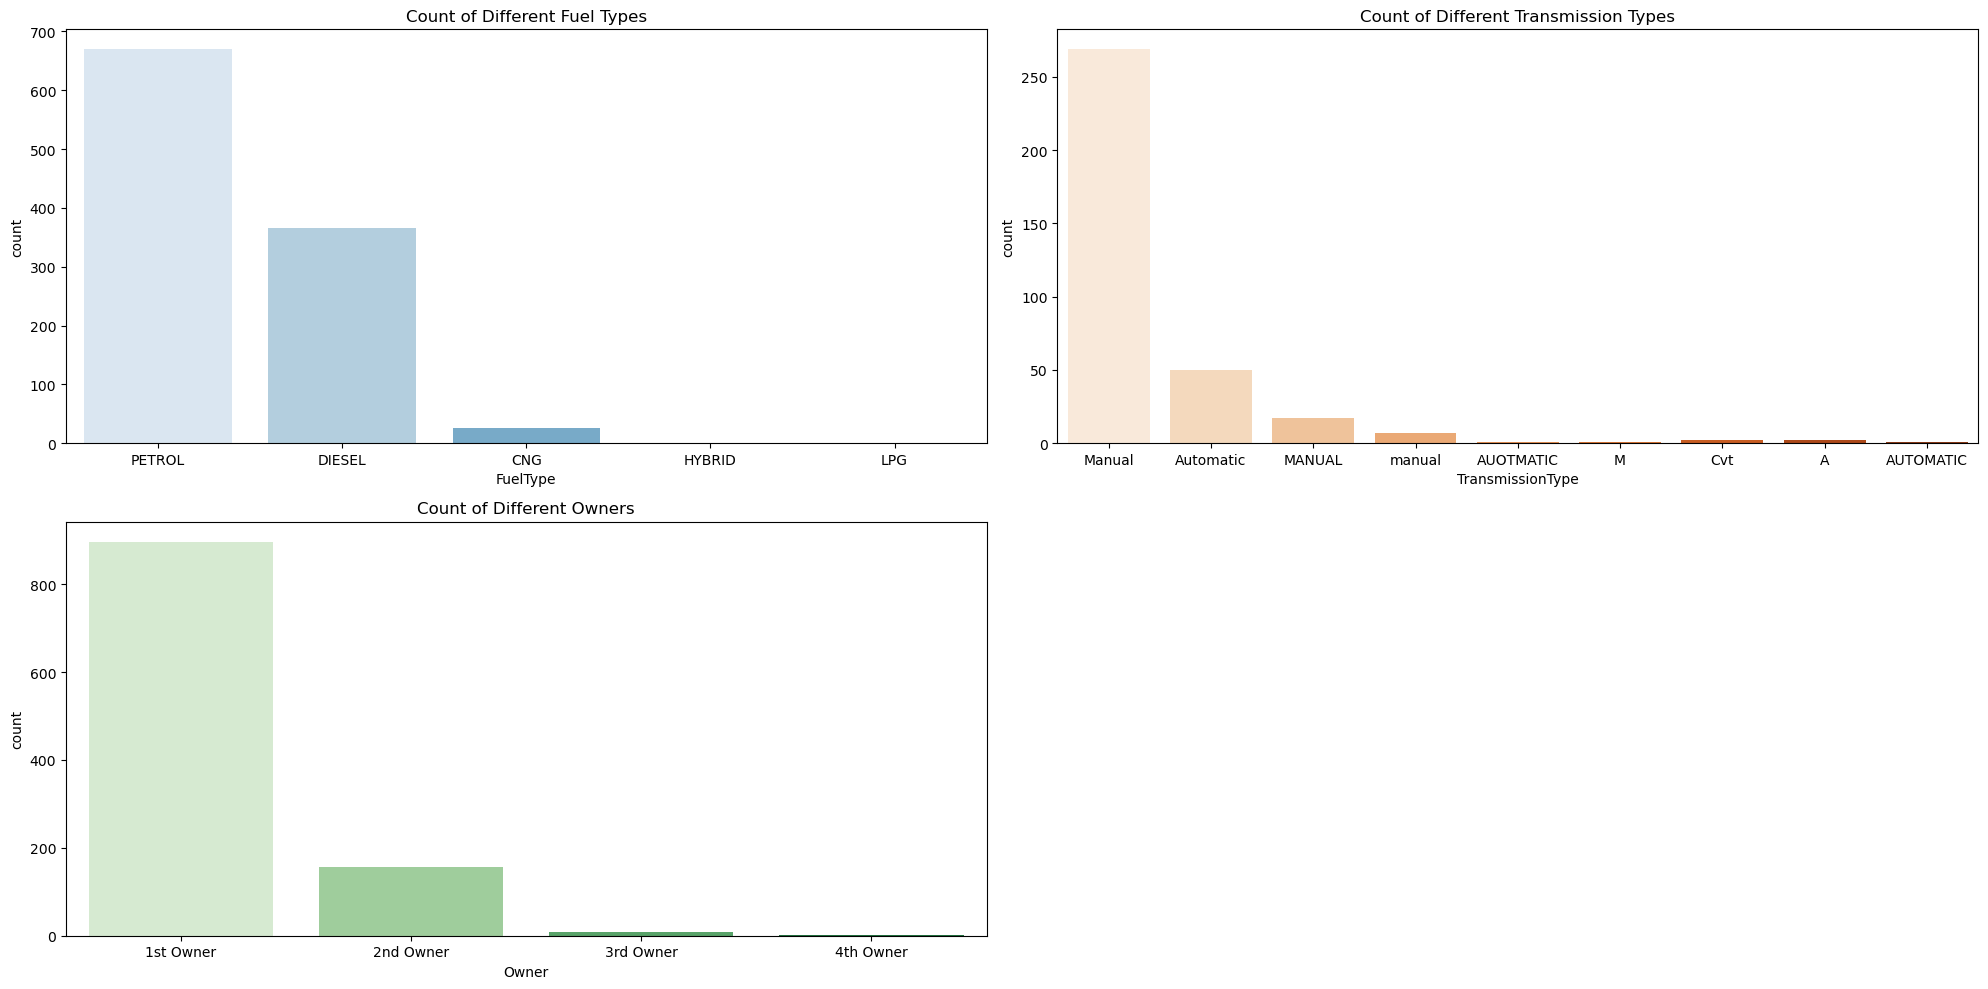

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 subplot
plt.figure(figsize=(20, 10))

# Subplot 1: Count of different Fuel Types
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='FuelType', palette='Blues')
plt.title("Count of Different Fuel Types")

# Subplot 2: Count of different Transmission Types
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='TransmissionType', palette='Oranges')
plt.title("Count of Different Transmission Types")

# Subplot 3: Count of different Owners
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Owner', palette='Greens')
plt.title("Count of Different Owners")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()



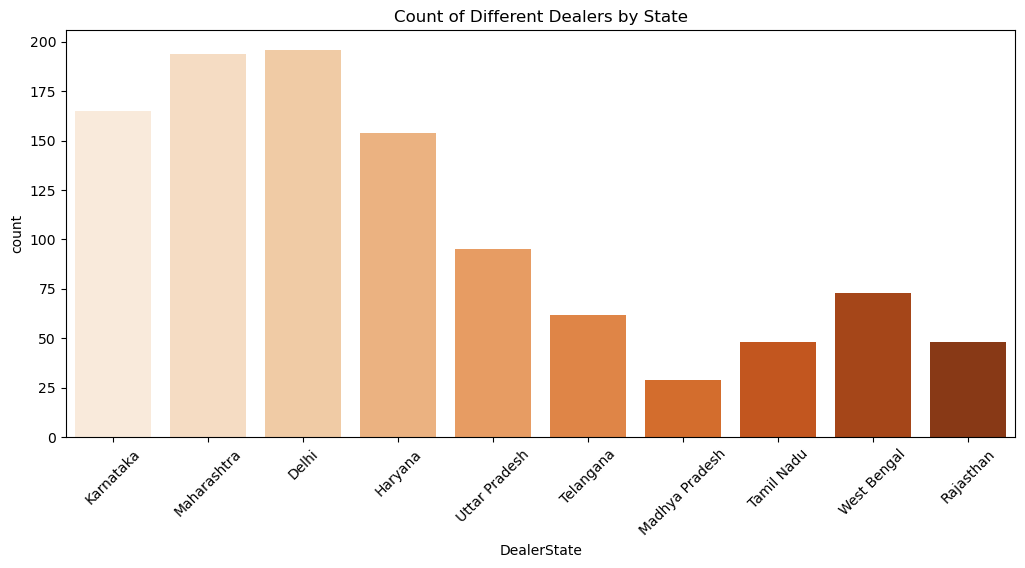

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 subplot
plt.figure(figsize=(20, 10))

# Subplot : Count of different Dealers by State
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='DealerState', palette='Oranges')
plt.title("Count of Different Dealers by State")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


What is/are the insight(s) found from the chart?
From the above plots we can analyse that:

The number of cars having their 'FuelType' type as Petrol is greater when compared to the other types namely: Diesel and CNG.
We can observe that most of the cars are sold in Delhi and Maharashtra when compared to the cities.
We clearly see that Manual cars are much more in number when compared to Automatic cars.
Most of the cars are sold by the First Owners and negligible number of cars are sold by the Third or Fourth Owners.

## Chart - 4 : Categorical Variable vs Target Variable

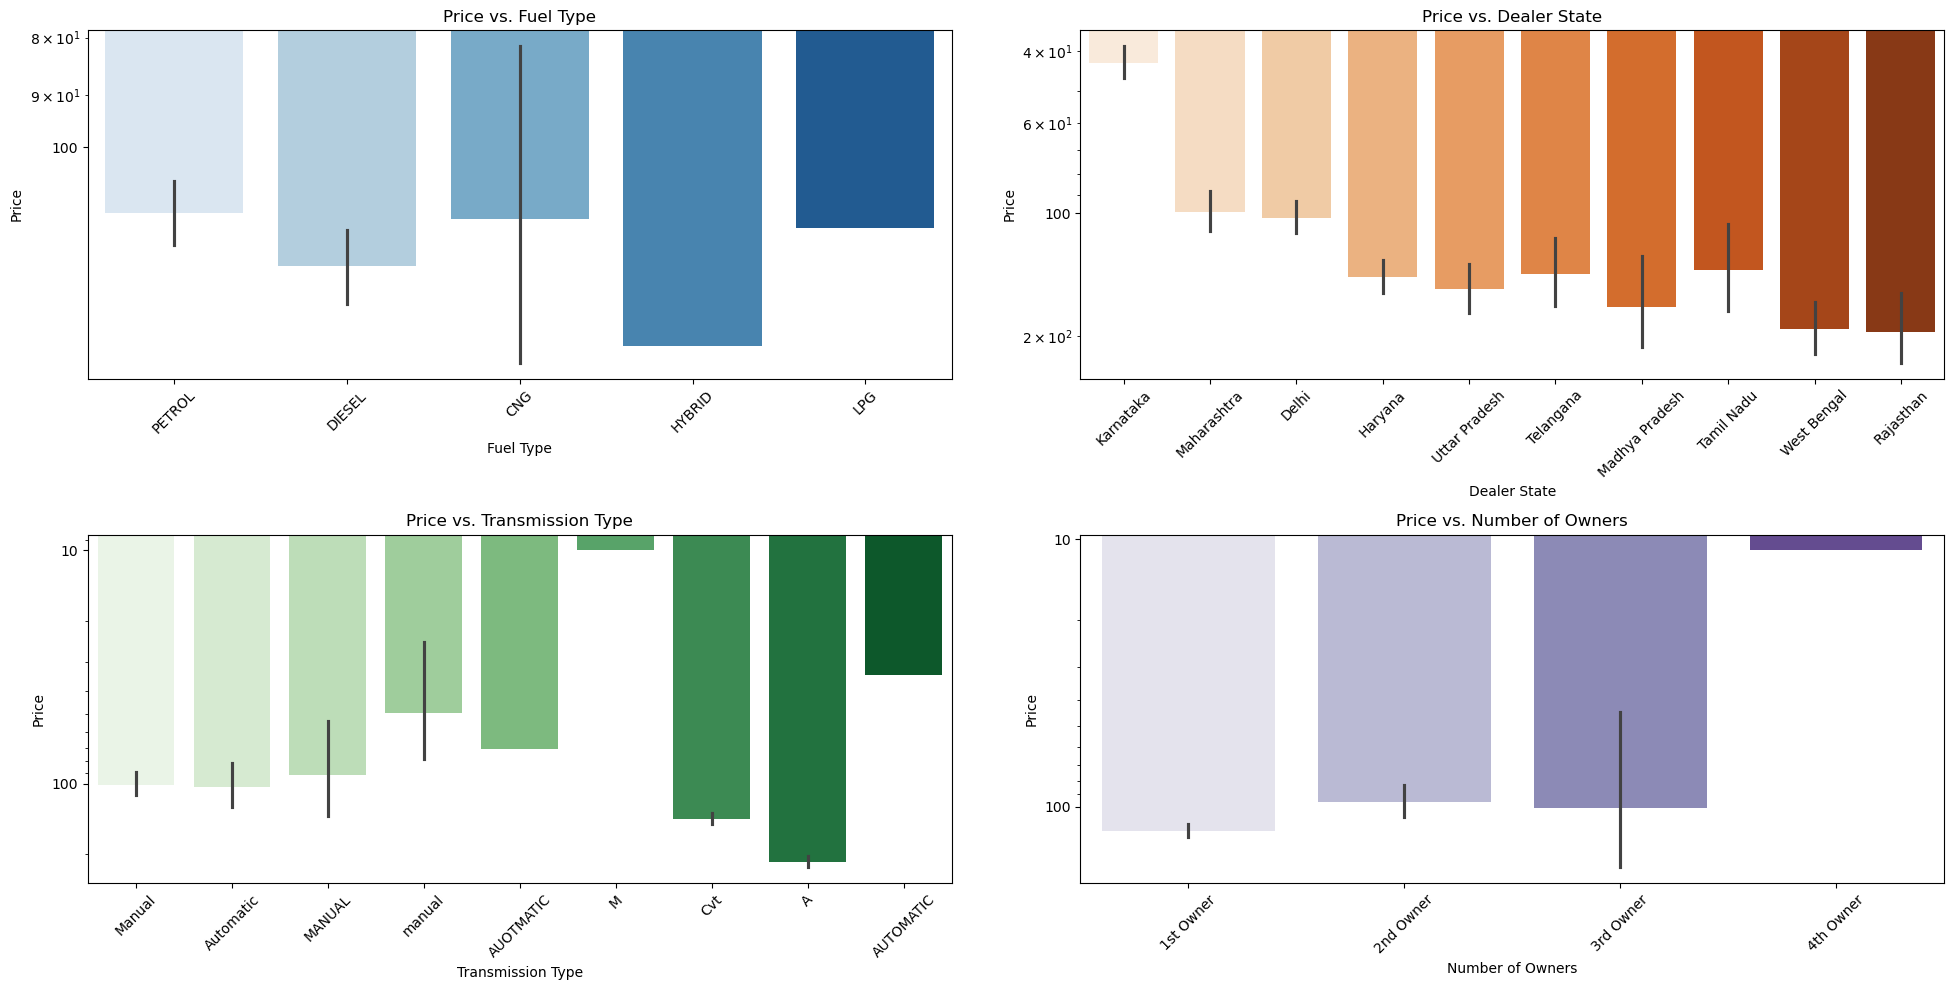

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Create a 2x2 subplot
plt.figure(figsize=(20, 10))

# Subplot 1: Barplot for Price vs. FuelType
plt.subplot(2, 2, 1)
sns.barplot(data=df, x='FuelType', y='Price', palette='Blues')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.title('Price vs. Fuel Type')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Subplot 2: Barplot for Price vs. DealerState
plt.subplot(2, 2, 2)
sns.barplot(data=df, x='DealerState', y='Price', palette='Oranges')
plt.xlabel('Dealer State')
plt.ylabel('Price')
plt.title('Price vs. Dealer State')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Subplot 3: Barplot for Price vs. TransmissionType
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='TransmissionType', y='Price', palette='Greens')
plt.xlabel('Transmission Type')
plt.ylabel('Price')
plt.title('Price vs. Transmission Type')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Subplot 4: Barplot for Price vs. Owner
plt.subplot(2, 2, 4)
sns.barplot(data=df, x='Owner', y='Price', palette='Purples')
plt.xlabel('Number of Owners')
plt.ylabel('Price')
plt.title('Price vs. Number of Owners')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Adjust y-axis scale and formatting for all subplots
for ax in plt.gcf().axes:
    ax.set_yscale('log')  # Apply logarithmic scale to y-axis
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Format y-axis labels with commas

# Display the plot
plt.show()



## Chart - 5 : Driven Kilometers vs Selling Price

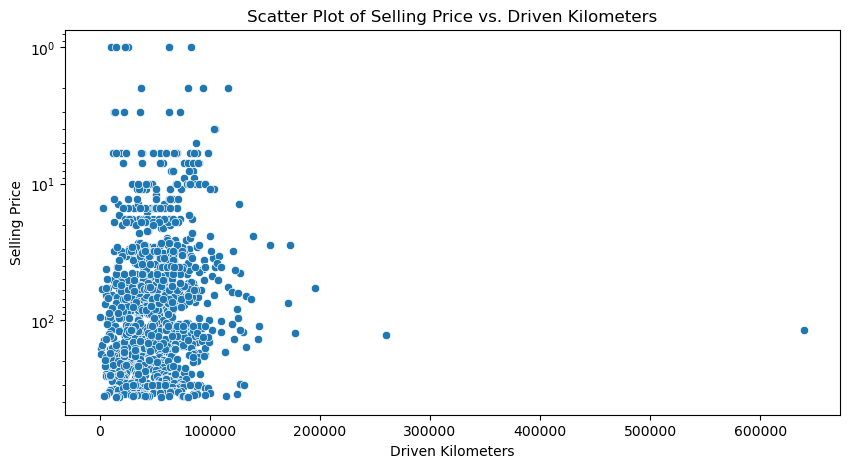

In [33]:
# Set the figure size for the plot
plt.figure(figsize=(10, 5))

# Create a scatter plot to visualize the relationship between Driven_Kms and Price
sns.scatterplot(data=df, x='Kilometer', y='Price')

# Set labels for the x and y axes
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')

# Add a title to the plot
plt.title('Scatter Plot of Selling Price vs. Driven Kilometers')

# Set the y-axis to a logarithmic scale
plt.yscale('log')

# Display the plot
plt.show()


## Chart - 6 - Correlation Heatmap

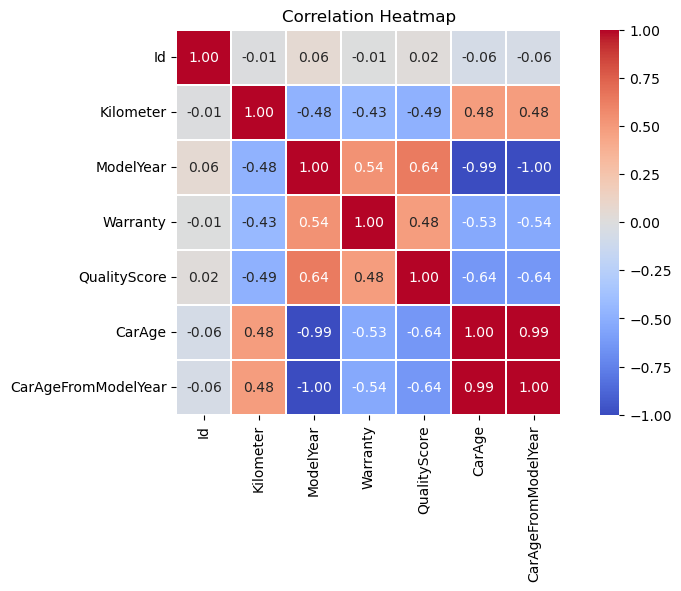

In [34]:
# Select only numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Set the size of the plot
plt.figure(figsize=(10, 5))

# Create a heatmap of the correlation matrix with annotations
sns.heatmap(numeric_df.corr(), annot=True, linewidths=0.1, fmt='.2f', square=True, cmap='coolwarm')

# Add a title to the plot
plt.title("Correlation Heatmap")

# Display the plot
plt.show()


## 5. Feature Engineering & Data Pre-processing

In [35]:
import numpy as np
import pandas as pd

# Convert 'Price' and other relevant columns to numeric (if they are stored as strings)
df['Price'] = df['Price'].replace({r'[^\d.]': ''}, regex=True)  # Remove any non-numeric characters like 'Lakhs'
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')  # Convert to numeric, invalid parsing will be NaN

# Convert 'Kilometer' to numeric
df['Kilometer'] = pd.to_numeric(df['Kilometer'], errors='coerce')

# Convert 'ModelYear' to numeric (if not already)
df['ModelYear'] = pd.to_numeric(df['ModelYear'], errors='coerce')

# Select numeric columns for outlier treatment (ignoring categorical columns)
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Handling outliers in 'Price' (Selling_Price) using IQR method
q1, q3, median = df['Price'].quantile([0.25, 0.75, 0.5])
lower_limit = q1 - 1.5 * (q3 - q1)
upper_limit = q3 + 1.5 * (q3 - q1)
df['Price'] = np.where(df['Price'] > upper_limit, median,
                       np.where(df['Price'] < lower_limit, median, df['Price']))

# Handling outliers by capping for numeric columns (except 'Price' which was already handled)
for col in numeric_columns:
    if col != 'Price':  # Skip the 'Price' column as it's already treated
        upper_limit = df[col].quantile(0.99)
        df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# After applying the changes, check the cleaned data
print(df.head())


         Id        Company               Model           Variant FuelType  \
0  555675.0  MARUTI SUZUKI  CELERIO(2017-2019)     1.0 ZXI AMT O   PETROL   
1  556383.0  MARUTI SUZUKI                ALTO               LXI   PETROL   
2  556422.0        HYUNDAI           GRAND I10    1.2 KAPPA ASTA   PETROL   
3  556771.0           TATA               NEXON           XT PLUS   PETROL   
4  559619.0           FORD                FIGO  EXI DURATORQ 1.4   DIESEL   

   Colour  Kilometer  BodyStyle TransmissionType ManufactureDate  ...  CngKit  \
0  Silver    33197.0  HATCHBACK              NaN      2018-02-01  ...     NaN   
1     Red    10322.0  HATCHBACK           Manual      2021-03-01  ...     NaN   
2    Grey    37889.0  HATCHBACK           Manual      2015-03-01  ...     NaN   
3  A Blue    13106.0  HATCHBACK              NaN      2020-08-01  ...     NaN   
4  Silver   104614.0  HATCHBACK           Manual      2010-11-01  ...     NaN   

  Price      Owner DealerState                    

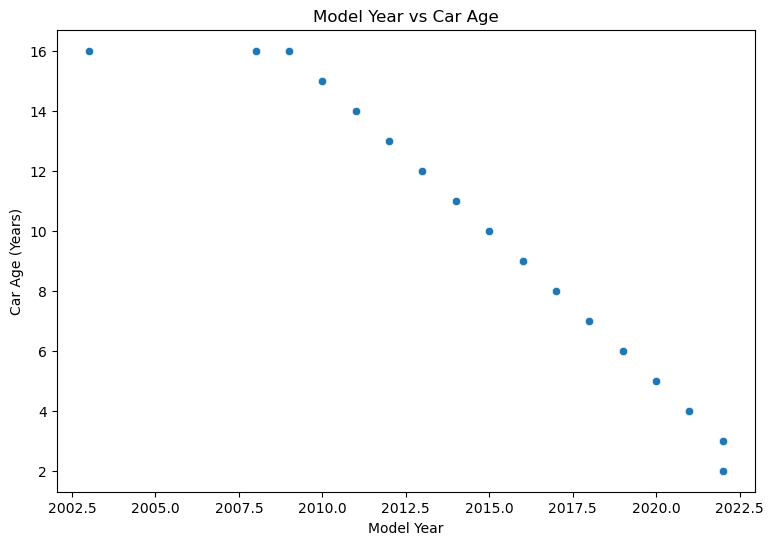

In [36]:
# Ensure the column name is correct (no extra space at the end)
plt.figure(figsize=(9, 6))
sns.scatterplot(x='ModelYear', y='CarAgeFromModelYear', data=df)  # Removed extra space in column name
plt.xlabel('Model Year')
plt.ylabel('Car Age (Years)')
plt.title('Model Year vs Car Age')
plt.show()


In [37]:
# Correlation
df[['ModelYear','CarAgeFromModelYear']].corr()

,ModelYear,CarAgeFromModelYear
ModelYear,1.000000,-0.997558
CarAgeFromModelYear,-0.997558,1.000000


In [38]:
# Select your features wisely to avoid overfitting
features = [i for i in df.columns if i not in ['Price']]
features
     

['Id',
 'Company',
 'Model',
 'Variant',
 'FuelType',
 'Colour',
 'Kilometer',
 'BodyStyle',
 'TransmissionType',
 'ManufactureDate',
 'ModelYear',
 'CngKit',
 'Owner',
 'DealerState',
 'DealerName',
 'City',
 'Warranty',
 'QualityScore',
 'CarAge',
 'CarAgeFromModelYear']

In [39]:
# Remove multicollinearity by using VIF technique
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [40]:
continuous_variables = ['Price', 'Kilometer', 'Owner', 'CarAgeFromModelYear']

In [41]:
continuous_feature_df = pd.DataFrame(df[continuous_variables])
     

In [42]:
continuous_feature_df

,Price,Kilometer,Owner,CarAgeFromModelYear
0,5.75,33197.0,1st Owner,7.0
1,4.35,10322.0,1st Owner,4.0
2,4.70,37889.0,1st Owner,10.0
3,9.90,13106.0,1st Owner,5.0
4,2.70,104614.0,2nd Owner,15.0
...,...,...,...,...
1059,7.15,42918.0,1st Owner,5.0
1060,5.00,78910.0,1st Owner,6.0
1061,5.75,76000.0,1st Owner,12.0
1062,7.71,80120.0,1st Owner,7.0


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Encode 'Owner' column
le = LabelEncoder()
continuous_feature_df['Owner'] = le.fit_transform(continuous_feature_df['Owner'])

# Ensure all columns are numeric
continuous_feature_df = continuous_feature_df.select_dtypes(include=[np.number])

# Replace infinite values and drop NaN rows
continuous_feature_df = continuous_feature_df.replace([np.inf, -np.inf], np.nan).dropna()

# Define VIF calculation function
def calc_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

# Calculate VIF
vif_result = calc_vif(continuous_feature_df)
print(vif_result)


             variables       VIF
0                Price  2.805173
1            Kilometer  6.816253
2                Owner  1.290582
3  CarAgeFromModelYear  7.333998


In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(data):
    # Ensure numeric data
    data = data.select_dtypes(include=[np.number])

    # Calculate VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data.columns
    vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_data

# Prepare the DataFrame
numeric_data = df[[i for i in continuous_feature_df]].select_dtypes(include=[np.number]).dropna()

# Compute VIF
vif_result = calc_vif(numeric_data)
print(vif_result)


               Feature       VIF
0                Price  2.758650
1            Kilometer  6.789673
2  CarAgeFromModelYear  7.040450


In [45]:
# This is the final data for modeling
df.head()
     

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,...,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore,CarAge,CarAgeFromModelYear
0,555675.0,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197.0,HATCHBACK,NaN,2018-02-01,...,NaN,5.75,1st Owner,Karnataka,Top Gear Cars,Bangalore,1.0,7.8,6.0,7.0
1,556383.0,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322.0,HATCHBACK,Manual,2021-03-01,...,NaN,4.35,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1.0,8.3,3.0,4.0
2,556422.0,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889.0,HATCHBACK,Manual,2015-03-01,...,NaN,4.70,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1.0,7.9,9.0,10.0
3,556771.0,TATA,NEXON,XT PLUS,PETROL,A Blue,13106.0,HATCHBACK,NaN,2020-08-01,...,NaN,9.90,1st Owner,Karnataka,Adeep Motors,Bangalore,1.0,8.1,4.0,5.0
4,559619.0,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614.0,HATCHBACK,Manual,2010-11-01,...,NaN,2.70,2nd Owner,Karnataka,Zippy Automart,Bangalore,0.0,7.5,14.0,15.0


In [46]:
print(df.columns)


Index(['Id', 'Company', 'Model', 'Variant', 'FuelType', 'Colour', 'Kilometer',
       'BodyStyle', 'TransmissionType', 'ManufactureDate', 'ModelYear',
       'CngKit', 'Price', 'Owner', 'DealerState', 'DealerName', 'City',
       'Warranty', 'QualityScore', 'CarAge', 'CarAgeFromModelYear'],
      dtype='object')


## Data Transformation

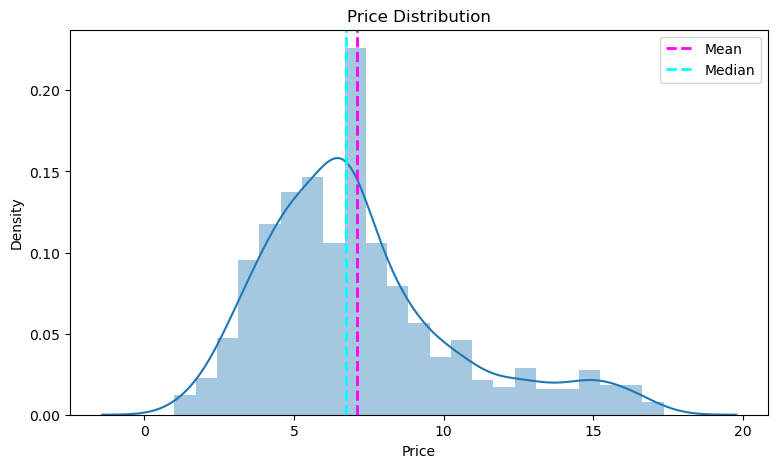

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set dependent variable to 'Price'
dependent_variable = "Price"

# Plot the distribution of the 'Price' column
plt.figure(figsize=(9, 5))
sns.distplot(df[dependent_variable])
plt.xlabel("Price")
plt.title("Price Distribution")
plt.axvline(df[dependent_variable].mean(), color="magenta", linestyle="dashed", linewidth=2, label="Mean")
plt.axvline(df[dependent_variable].median(), color="cyan", linestyle="dashed", linewidth=2, label="Median")
plt.legend()
plt.show()


In [48]:
# Skew of the dependent variable
df[dependent_variable].skew()
     

1.0226674051446376

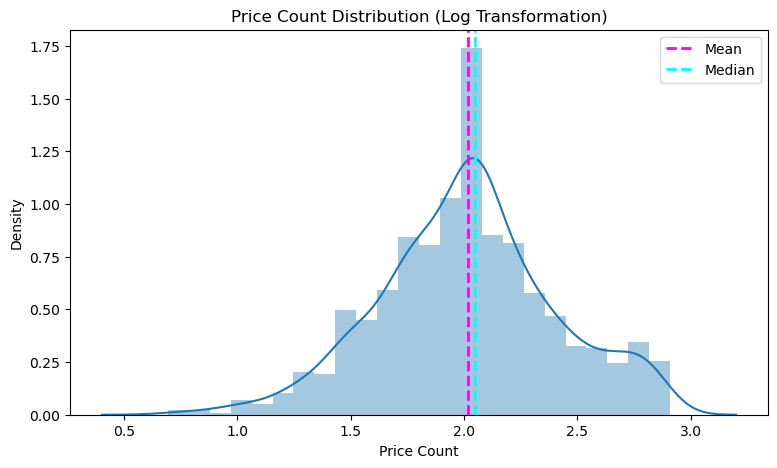

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the dependent variable to 'Price'
dependent_variable = "Price"

# Visualizing the distribution of the dependent variable after log transformation
plt.figure(figsize=(9, 5))
sns.distplot(np.log1p(df[dependent_variable]))  # Apply log transformation
plt.xlabel('Price Count')
plt.title('Price Count Distribution (Log Transformation)')

# Add vertical lines for the mean and median of the log-transformed 'Price'
plt.axvline(np.log1p(df[dependent_variable]).mean(), color='magenta', linestyle='dashed', linewidth=2, label="Mean")
plt.axvline(np.log1p(df[dependent_variable]).median(), color='cyan', linestyle='dashed', linewidth=2, label="Median")

# Display legend
plt.legend()

# Show the plot
plt.show()


In [50]:
# Skew of the dependent variable after log transformation
np.log1p(df[dependent_variable]).skew()

-0.05322312023659758

In [51]:
# Defining dependent and independent variables
X = df.drop('Price',axis=1)
y = np.log1p(df[dependent_variable])
     


In [52]:
features

['Id',
 'Company',
 'Model',
 'Variant',
 'FuelType',
 'Colour',
 'Kilometer',
 'BodyStyle',
 'TransmissionType',
 'ManufactureDate',
 'ModelYear',
 'CngKit',
 'Owner',
 'DealerState',
 'DealerName',
 'City',
 'Warranty',
 'QualityScore',
 'CarAge',
 'CarAgeFromModelYear']

##  Data Scaling

In [53]:
features = [i for i in df.columns if i not in ['Price']]

In [54]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


# Check the feature list
features = ['Kilometer', 'ModelYear', 'Price']  

# Handle categorical variables (if any)
df = pd.get_dummies(df, columns=['FuelType', 'TransmissionType'], drop_first=True)

# Ensure features are numeric
numeric_features = df.select_dtypes(include=['number']).columns
features = [f for f in features if f in numeric_features]

# Scale the numeric features
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
print("Scaled data:", X)

Scaled data: [[-0.68724278  0.38172781 -0.41962927]
 [-1.52309196  1.38624157 -0.85062068]
 [-0.51579779 -0.62278594 -0.74287283]
 ...
 [ 0.87677262 -1.29246177 -0.41962927]
 [ 1.02731683  0.38172781  0.18375869]
 [ 0.93158241 -0.95762386 -0.65359604]]


## Data Splitting

In [57]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [58]:
# Checking the train distribution of dependent variable
y_train.value_counts()

Price
2.047693    74
1.981001    17
2.251292    15
1.938742    12
1.504077    12
            ..
1.894617     1
2.013569     1
2.395164     1
1.435085     1
2.248129     1
Name: count, Length: 270, dtype: int64

## ML Model Implementation

In [59]:
# Defining a function to print evaluation matrix
def evaluate_model(model, y_test, y_pred):

  '''takes model, y test and y pred values to print evaluation metrics, plot the actual and predicted values,
  plot the top 5 important features, and returns a list of the model scores'''

  # Apply inverse log transformation to y_test and y_pred as we have used log transformation
  y_t = np.exp(y_test)
  y_p = np.exp(y_pred)
  y_train2 = np.exp(y_train)
  y_train_pred = np.exp(model.predict(X_train))

  # Calculating Evaluation Matrix
  mse = mean_squared_error(y_t,y_p)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_t,y_p)
  r2_train = r2_score(y_train2, y_train_pred)
  r2 = r2_score(y_t,y_p)
  r2_adjusted = 1-(1-r2)*((len(X_test)-1)/(len(X_test)-X_test.shape[1]-1))

  # Printing Evaluation Matrix
  print("MSE :" , mse)
  print("RMSE :" ,rmse)
  print("MAE :" ,mae)
  print("Train R2 :" ,r2_train)
  print("Test R2 :" ,r2)
  print("Adjusted R2 : ", r2_adjusted)


  # plot actual and predicted values
  plt.figure(figsize=(12,4))
  plt.plot((y_p)[:100])
  plt.plot((np.array(y_t)[:100]))
  plt.legend(["Predicted","Actual"])
  plt.title('Actual and Predicted Selling Price', fontsize=12)

  try:
    importance = model.feature_importances_
  except:
    importance = model.coef_
  importance = np.absolute(importance)
  if len(importance)==len(features):
    pass
  else:
    importance = importance[0]

  # Feature importances
  feat = pd.Series(importance, index=features)
  plt.figure(figsize=(7,4))
  plt.title('Feature Importances (top 5) for '+str(model), fontsize = 12)
  plt.xlabel('Relative Importance')
  feat.nlargest(5).plot(kind='barh')


  model_score = [mse,rmse,mae,r2_train,r2,r2_adjusted]
  return model_score
     

In [60]:
# Create a score dataframe
score = pd.DataFrame(index = ['MSE', 'RMSE', 'MAE', 'Train R2', 'Test R2', 'Adjusted R2'])

## ML Model - 1 : Linear Regression

In [61]:
# Import the LinearRegression class
reg = LinearRegression()

# Fit the linear regression model to the training data
reg.fit(X_train, y_train)

# Predict on the model
y_pred_li = reg.predict(X_test)

MSE : 0.8719051264665151
RMSE : 0.9337586018166125
MAE : 0.5534661045833094
Train R2 : 0.9147013363521335
Test R2 : 0.9237115116532109
Adjusted R2 :  0.9229872538524502


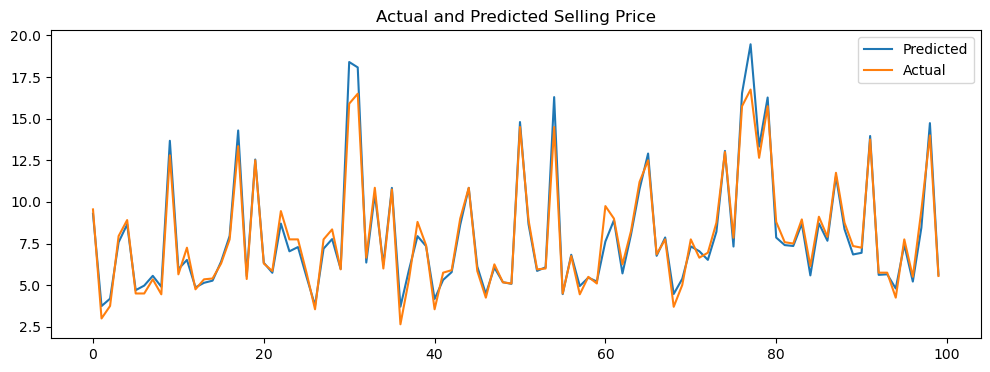

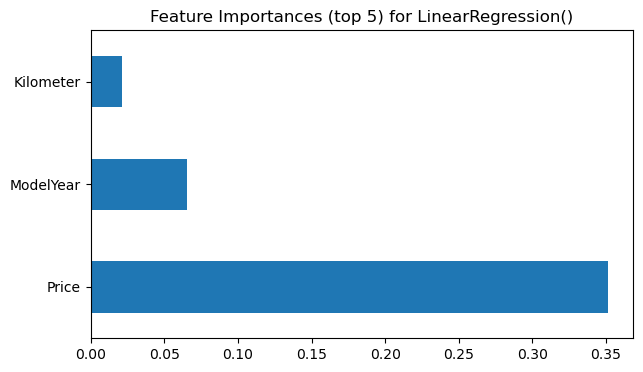

In [62]:
# Visualizing evaluation Metric Score chart
linear_score = evaluate_model(reg, y_test,y_pred_li)
score['Linear regression'] = linear_score

In [63]:

# Updated Evaluation Metric Score chart
score

,Linear regression
MSE,0.871905
RMSE,0.933759
MAE,0.553466
Train R2,0.914701
Test R2,0.923712
Adjusted R2,0.922987


## Cross- Validation & Hyperparameter Tuning

In [64]:
# Define the model
reg = LinearRegression()

# Define the parameters to be optimized
param_grid = {'fit_intercept': [True, False]}

# Perform grid search
grid_search = GridSearchCV(reg, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]},
             return_train_score=True, scoring='r2')

In [65]:
# Print the best parameters and the corresponding score
print("Best parameters: ", grid_search.best_params_)
print("Best R2 score: ", grid_search.best_score_)

Best parameters:  {'fit_intercept': True}
Best R2 score:  0.9422803063055522


In [66]:
# Use the best parameter to train the model
best_reg = grid_search.best_estimator_
best_reg.fit(X_train, y_train)
     

LinearRegression()

In [67]:
# Predict on test data
y_pred_li2 = best_reg.predict(X_test)
     

MSE : 0.8719051264665151
RMSE : 0.9337586018166125
MAE : 0.5534661045833094
Train R2 : 0.9147013363521335
Test R2 : 0.9237115116532109
Adjusted R2 :  0.9229872538524502


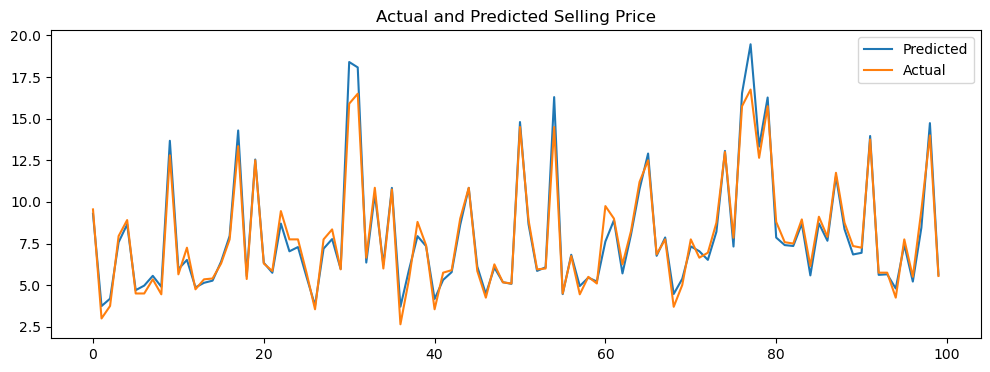

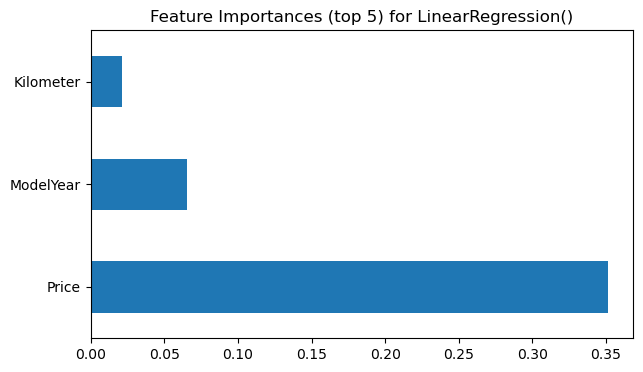

In [68]:
# Visualizing evaluation Metric Score chart
linear_score2 = evaluate_model(best_reg, y_test,y_pred_li2)

In [69]:

# Updated Evaluation Metric Score chart
score['Linear regression tuned'] = linear_score2
score

,Linear regression,Linear regression tuned
MSE,0.871905,0.871905
RMSE,0.933759,0.933759
MAE,0.553466,0.553466
Train R2,0.914701,0.914701
Test R2,0.923712,0.923712
Adjusted R2,0.922987,0.922987


## ML Model - 2 : Lasso Regression

In [70]:
# Import the Lasso Regression class
lasso = Lasso()

# Fit the lasso regression model to the training data
lasso.fit(X_train, y_train)

# Predict on the model
y_pred_lasso1 = lasso.predict(X_test)

MSE : 11.958380776435067
RMSE : 3.458089179942453
MAE : 2.5362238036920344
Train R2 : -0.03272772751130337
Test R2 : -0.0463142890404491
Adjusted R2 :  -0.05624765254399766


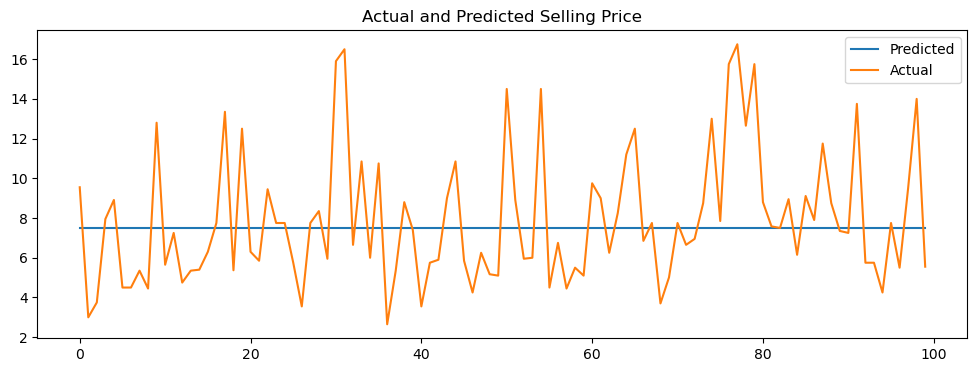

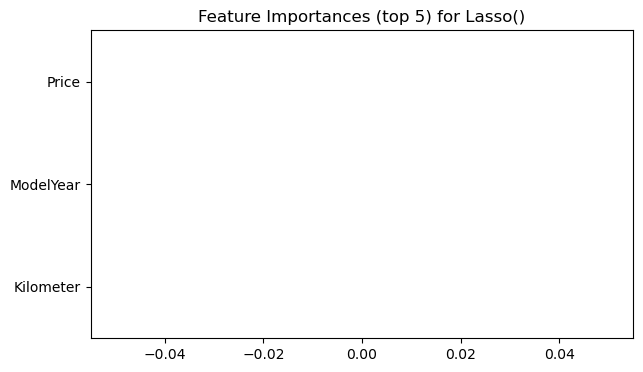

In [71]:
# Visualizing evaluation Metric Score chart
lasso_score = evaluate_model(lasso, y_test,y_pred_lasso1)
score['Lasso regression'] = lasso_score

In [72]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression
MSE,0.871905,0.871905,11.958381
RMSE,0.933759,0.933759,3.458089
MAE,0.553466,0.553466,2.536224
Train R2,0.914701,0.914701,-0.032728
Test R2,0.923712,0.923712,-0.046314
Adjusted R2,0.922987,0.922987,-0.056248


It is seen that using Lasso regression analysis the performance of the model has drop down. So i will try to tuned the model.

##  Cross- Validation & Hyperparameter Tuning


In [73]:
# Define the model
lasso = Lasso()

# Define the parameters to be optimized & Perform grid search
parameters = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,100]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error', cv=5)

# Fitting model
lasso_regressor.fit(X_train,y_train)
     

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 1e-05, 0.0001, 0.001,
                                   0.01, 1, 5, 10, 20, 30, 40, 45, 50, 55, 60,
                                   100]},
             scoring='neg_mean_squared_error')

In [74]:
# Getting optimum parameters
print("The optimum alpha value is found out to be :" ,lasso_regressor.best_params_)
print("\nUsing ",lasso_regressor.best_params_, " the negative mean squared error is: ", lasso_regressor.best_score_)

The optimum alpha value is found out to be : {'alpha': 1e-05}

Using  {'alpha': 1e-05}  the negative mean squared error is:  -0.008427982039516104


In [75]:
# Import the Lasso Regression class with best alpha
lasso = Lasso(alpha = lasso_regressor.best_params_['alpha'])

# Fit the lasso regression model to your training data
lasso.fit(X_train, y_train)

# Predict the model
y_pred_lassocv = lasso.predict(X_test)

MSE : 0.871695955997841
RMSE : 0.9336465905244024
MAE : 0.5534294199964729
Train R2 : 0.9147203268104839
Test R2 : 0.9237298132990867
Adjusted R2 :  0.9230057292481286


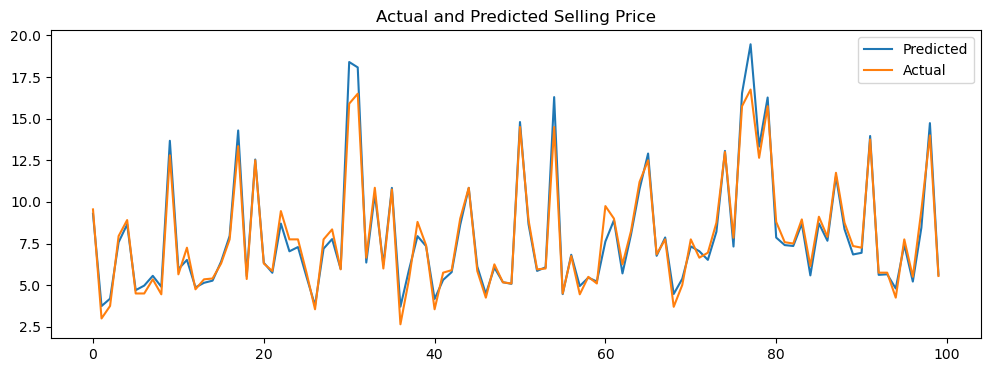

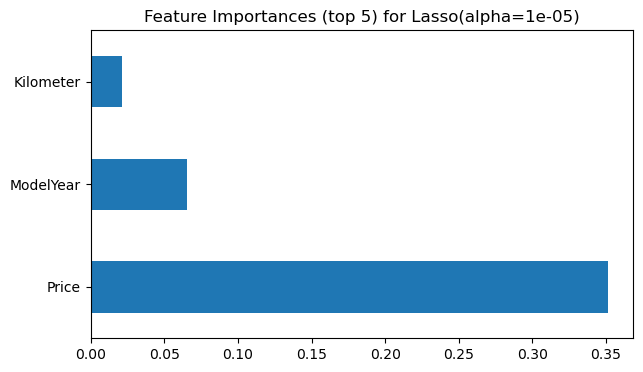

In [76]:
#Evaluation matrices for Lasso regression
lasso2 = evaluate_model(lasso, y_test,y_pred_lassocv)

name = 'Lasso with alpha = ' + str(lasso_regressor.best_params_['alpha'])

score[name] = lasso2

Which hyperparameter optimization technique have you used and why?
GridSearchCV is used to find the best hyperparameters for a machine learning model by searching over a specified parameter grid. It helps to ensure that a model is not overfitting or underfitting by evaluating the model's performance using cross-validation techniques. GridSearchCV can save time and resources compared to manually tuning the parameters of a model.

To reduce time and effort i have used GridSearchCV.

In [77]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05
MSE,0.871905,0.871905,11.958381,0.871696
RMSE,0.933759,0.933759,3.458089,0.933647
MAE,0.553466,0.553466,2.536224,0.553429
Train R2,0.914701,0.914701,-0.032728,0.914720
Test R2,0.923712,0.923712,-0.046314,0.923730
Adjusted R2,0.922987,0.922987,-0.056248,0.923006


## ML Model - 3 : Ridge Regression

In [132]:
# Ridge regressor class
ridge = Ridge()

# Fit the ridge regression model to your training data
ridge.fit(X_train, y_train)

# Predict on the model
y_pred_ridge1 = ridge.predict(X_test)
     

 Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MSE : 0.8621460558957811
RMSE : 0.9285182043965433
MAE : 0.551853536488063
Train R2 : 0.9156102675799103
Test R2 : 0.9245653943967704
Adjusted R2 :  0.9238492430777524


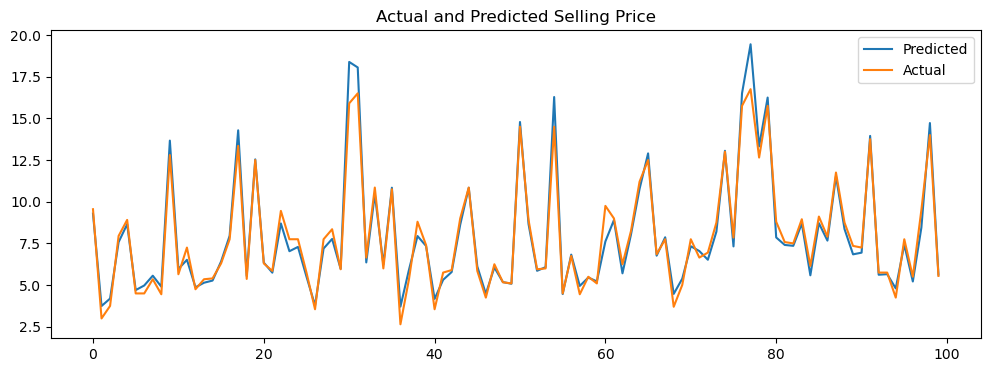

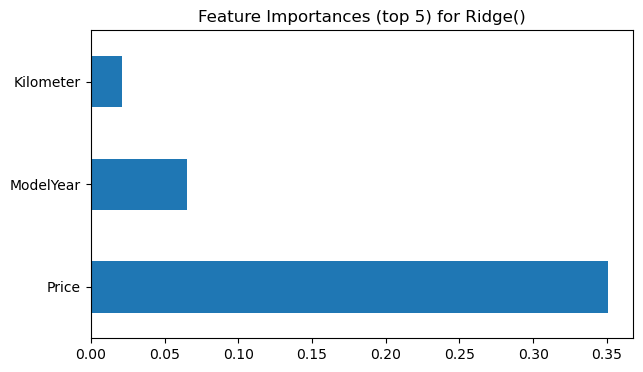

In [133]:

# Visualizing evaluation Metric Score chart
result = evaluate_model(ridge, y_test,y_pred_ridge1)
score['Ridge'] = result
     

In [134]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor,Gradient Boosting Regressor Tuned,Extreme Gradient Boosting Regressor,Extreme Gradient Boosting Regressor Tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762,0.012092,0.004880,0.004880
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609,0.109964,0.069860,0.069860
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627,0.043447,0.033823,0.033823
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970,0.999466,0.999973,0.999973
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933,0.998942,0.999573,0.999573
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933,0.998932,0.999569,0.999569


I have used Ridge regression technique to check the performance of the model and i have found that there is no majorly difference in between linear regression and Ridge. Both models are quite similar.

## Cross- Validation & Hyperparameter Tuning

In [135]:
# Import Ridge regressor Class
ridge = Ridge()

# Define the parameters to be optimized & Perform grid search
parameters = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error', cv=5)

# Fitting model
ridge_regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 1e-05, 0.0001, 0.001,
                                   0.01, 1, 5, 10, 20, 30, 40, 45, 50, 55, 60,
                                   100]},
             scoring='neg_mean_squared_error')

In [136]:
# Getting optimum parameters
print("The best fit alpha value is found out to be :" ,ridge_regressor.best_params_)
print("\nUsing ",ridge_regressor.best_params_, " the negative mean squared error is: ", ridge_regressor.best_score_)
     

The best fit alpha value is found out to be : {'alpha': 5}

Using  {'alpha': 5}  the negative mean squared error is:  -0.008416095920635313


In [137]:

# Initiate ridge with best alpha
ridge = Ridge(alpha = ridge_regressor.best_params_['alpha'])

# Fit the ridge regression model to your training data
ridge.fit(X_train, y_train)

# Predict on model
y_pred_ridge = ridge.predict(X_test)
     

MSE : 0.8248930060743579
RMSE : 0.9082362061018917
MAE : 0.5456131290071341
Train R2 : 0.9190915634120769
Test R2 : 0.9278248990962111
Adjusted R2 :  0.9271396924420612


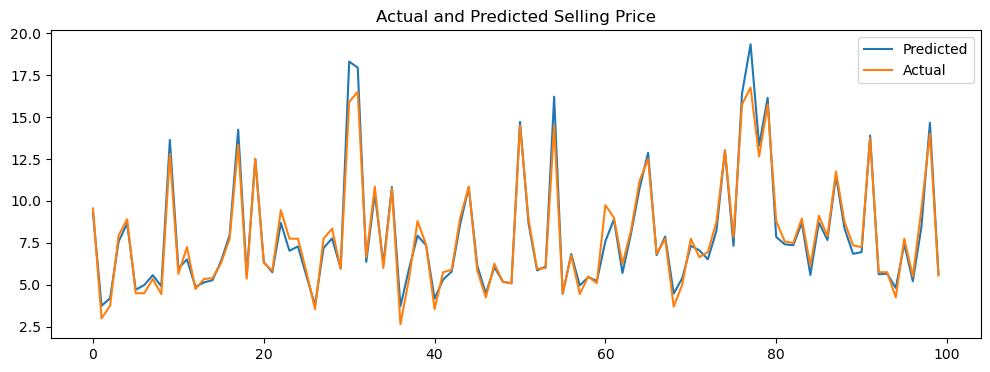

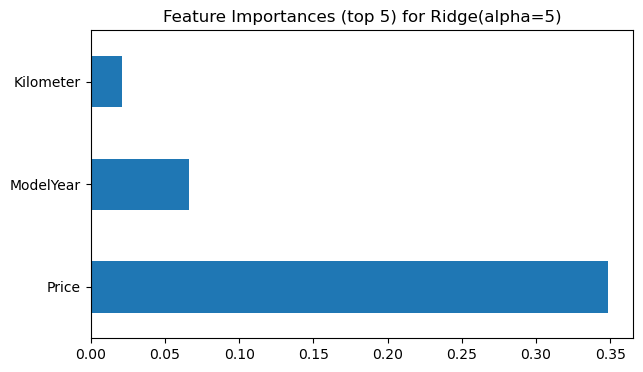

In [138]:
# Evaluation matrices for Ridge regression
result = evaluate_model(ridge, y_test,y_pred_ridge)

namer = 'Ridge with alpha = ' + str(ridge_regressor.best_params_['alpha'])

score[namer] = result
     

Which hyperparameter optimization technique have i used and why?
GridSearchCV is used to find the best hyperparameters for a machine learning model by searching over a specified parameter grid. It helps to ensure that a model is not overfitting or underfitting by evaluating the model's performance using cross-validation techniques. GridSearchCV can save time and resources compared to manually tuning the parameters of a model.

To reduce time and effort we have used GridSearchCV.

In [139]:
 # Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor,Gradient Boosting Regressor Tuned,Extreme Gradient Boosting Regressor,Extreme Gradient Boosting Regressor Tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762,0.012092,0.004880,0.004880
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609,0.109964,0.069860,0.069860
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627,0.043447,0.033823,0.033823
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970,0.999466,0.999973,0.999973
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933,0.998942,0.999573,0.999573
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933,0.998932,0.999569,0.999569


I have tuned Ridge regression using hyperparametric technique & check the performance of the model and i have found that the tuned Ridge regression model give the better accuracy compare to the untuned model for the test set.

## ML Model - 4 : Decision Tree

In [146]:
# Import Decision Tree Regressor class
dt = DecisionTreeRegressor(random_state=1)

# Fit the Decision Tree model to your training data
dt.fit(X_train,y_train)

# Predict on the model
y_pred_dt1 = dt.predict(X_test)
     

MSE : 0.0017043749999999882
RMSE : 0.04128407683356851
MAE : 0.013562500000001138
Train R2 : 1.0
Test R2 : 0.9998508734627436
Adjusted R2 :  0.9998494577044785


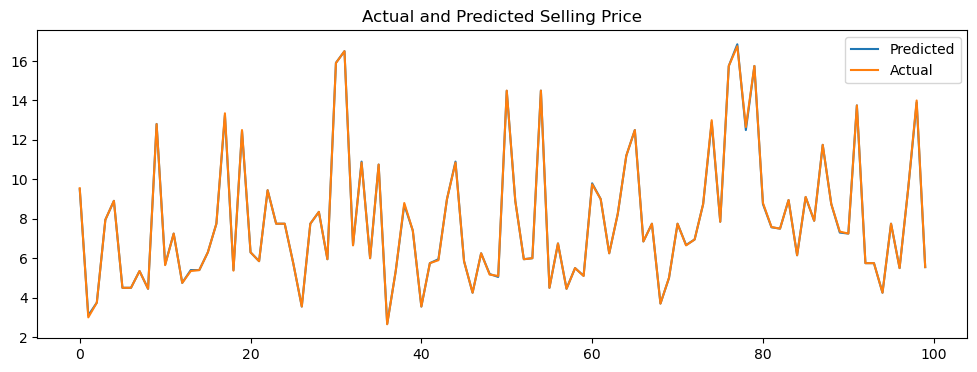

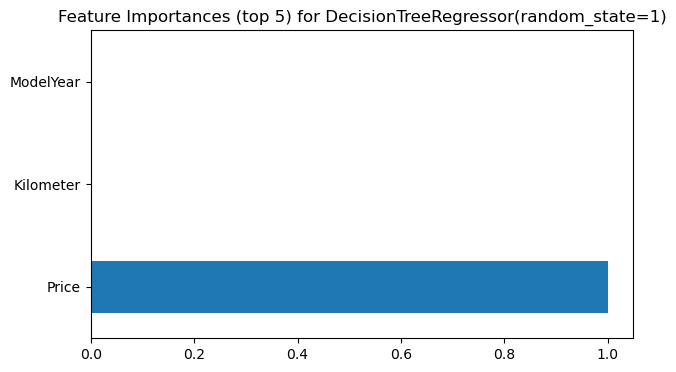

In [147]:

# Visualizing evaluation Metric Score chart
result = evaluate_model(dt, y_test,y_pred_dt1)
score['Decision tree'] = result

In [148]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor,Gradient Boosting Regressor Tuned,Extreme Gradient Boosting Regressor,Extreme Gradient Boosting Regressor Tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762,0.012092,0.004880,0.004880
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609,0.109964,0.069860,0.069860
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627,0.043447,0.033823,0.033823
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970,0.999466,0.999973,0.999973
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933,0.998942,0.999573,0.999573
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933,0.998932,0.999569,0.999569


From the decision tree algorithm i got train R2 score is 1 and test R2 score is 99% which shows the overfitting condition on train dataset.

So, i have decided to tune the data using GridSearchCV.

 ## Cross- Validation & Hyperparameter Tuning

In [89]:
# Regressor
dt_model = DecisionTreeRegressor(random_state=1)

# Hyperparameter Grid
grid = {'max_depth' : [8,10,12,14,16],
        'min_samples_split' : np.arange(35,50),
        'min_samples_leaf' : np.arange(22,31,2)}

# Fitting model with hypertuned paramaters using grid search
dt_gridsearch = GridSearchCV(dt_model,
                             grid,
                             cv=6,
                             scoring= 'neg_root_mean_squared_error')
dt_gridsearch.fit(X_train,y_train)
dt_best_params = dt_gridsearch.best_params_

In [90]:

dt_best_params

{'max_depth': 8, 'min_samples_leaf': 22, 'min_samples_split': 35}

In [91]:
# Building Decision Tree model with best parameters
dt_model = DecisionTreeRegressor(max_depth=dt_best_params['max_depth'],
                                 min_samples_leaf=dt_best_params['min_samples_leaf'],
                                 min_samples_split=dt_best_params['min_samples_split'],
                                 random_state=1)
     


In [92]:
# Fitting model
dt_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=22, min_samples_split=35,
                      random_state=1)

In [93]:

# Predict on the model
y_pred_dt = dt_model.predict(X_test)
     

MSE : 0.08699756422528428
RMSE : 0.2949534950213072
MAE : 0.18279512685051794
Train R2 : 0.9931780589842059
Test R2 : 0.9923880334417846
Adjusted R2 :  0.9923157679364851


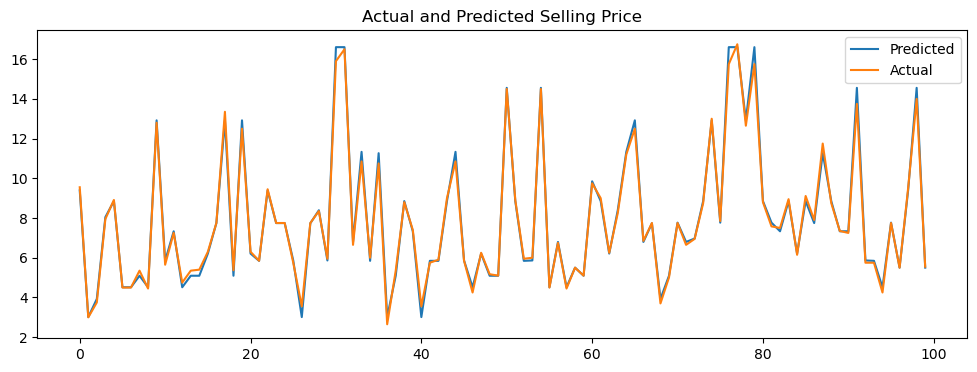

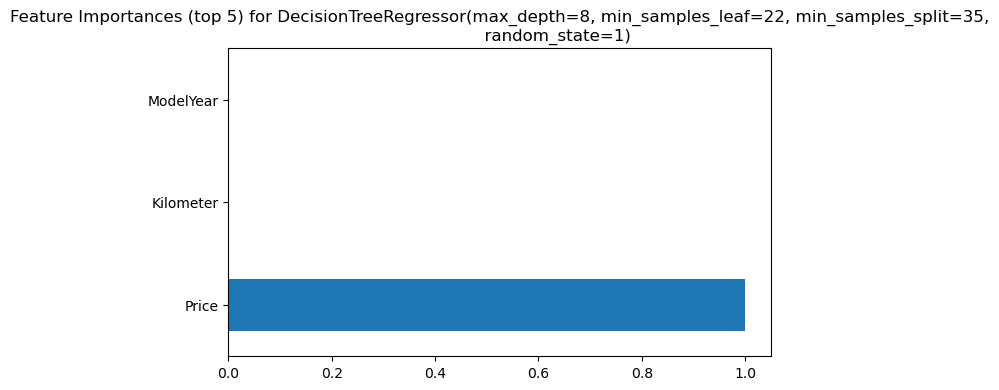

In [94]:
# Evaluation matrices for DecisionTree
result = evaluate_model(dt_model, y_test,y_pred_dt)
score['Decision tree tuned'] = result

Which hyperparameter optimization technique have i used and why?
GridSearchCV is used to find the best hyperparameters for a machine learning model by searching over a specified parameter grid. It helps to ensure that a model is not overfitting or underfitting by evaluating the model's performance using cross-validation techniques. GridSearchCV can save time and resources compared to manually tuning the parameters of a model.

To reduce time and effort we have used GridSearchCV.

Have i seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [95]:

# Updated Evaluation Metric Score Chart
score
     

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316


From the above tuned Decision tree regression, it has seen that earlier we have faced overfitting condition. After tuning no dfference was seen.

## ML Model - 5 : Random Forest

In [96]:
# Import Random Forest Regressor class
rf = RandomForestRegressor(random_state=0)

# Fit the Random Forest model to your training data
rf.fit(X_train,y_train)

# Predict on the model
y_pred_rf1 = rf.predict(X_test)

MSE : 0.0007623258151848013
RMSE : 0.02761024837238523
MAE : 0.011741636729461151
Train R2 : 0.9999878142552041
Test R2 : 0.9999332992979364
Adjusted R2 :  0.9999326660634231


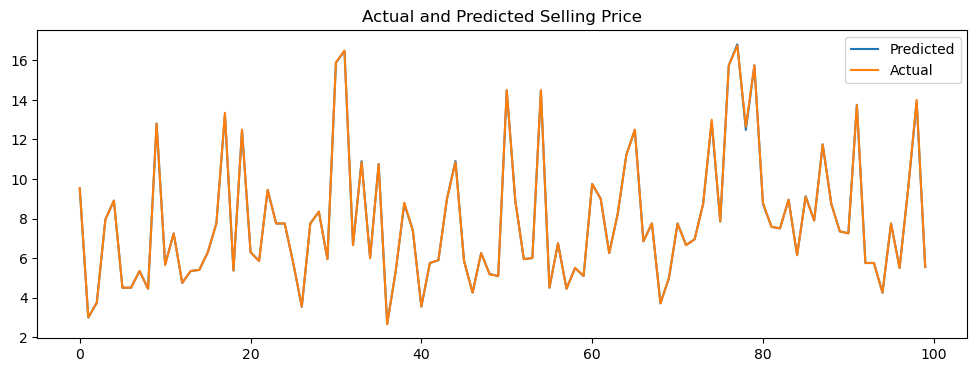

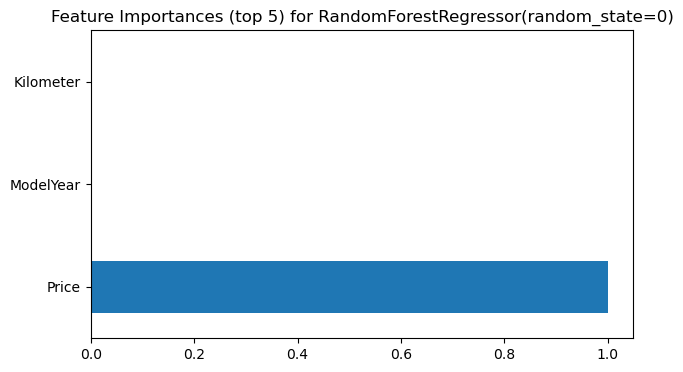

In [97]:

# Visualizing evaluation Metric Score chart
result = evaluate_model(rf, y_test,y_pred_rf1)
score['Random forest'] = result
     

In [98]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933


Here i have seen that using random forest, regression accuracy of the train and test model increases 99% and 99% respectively, which seems to be a good model for prediction.

## Cross- Validation & Hyperparameter Tuning

In [99]:
# Random forest model
rf_model = RandomForestRegressor(random_state=0)
rf_params = {'n_estimators':[300],                    # limited due to computational power availability
             'min_samples_leaf':np.arange(20,25)}     # Approximate range from a decision tree model
     

In [100]:
# Fitting a Random Forest model with best parameters obtained from gridsearch
rf_gridsearch = GridSearchCV(rf_model,rf_params,cv=6,scoring='neg_root_mean_squared_error')
rf_gridsearch.fit(X_train,y_train)
rf_best_params = rf_gridsearch.best_params_

In [101]:
# Best parameters for random forests
rf_best_params

{'min_samples_leaf': 20, 'n_estimators': 300}

In [102]:
# Building Random Forest model with best parameters
rf_model = RandomForestRegressor(n_estimators=rf_best_params['n_estimators'],
                                 min_samples_leaf=rf_best_params['min_samples_leaf'],
                                 random_state=0)
     

In [103]:
# Fitting model
rf_model.fit(X_train,y_train)
     

RandomForestRegressor(min_samples_leaf=20, n_estimators=300, random_state=0)

In [104]:
# Predict on the model
y_pred_rf = rf_model.predict(X_test)
     

MSE : 0.0776790544394432
RMSE : 0.2787096238730252
MAE : 0.13818055569278345
Train R2 : 0.9935915234977145
Test R2 : 0.9932033687387424
Adjusted R2 :  0.993138843758414


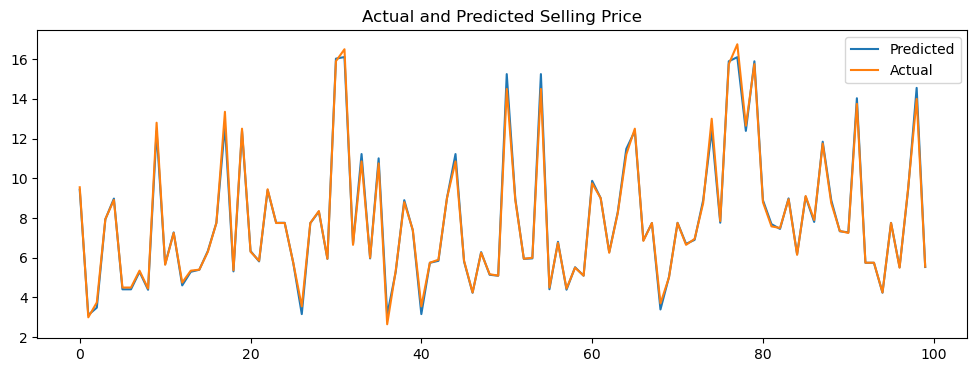

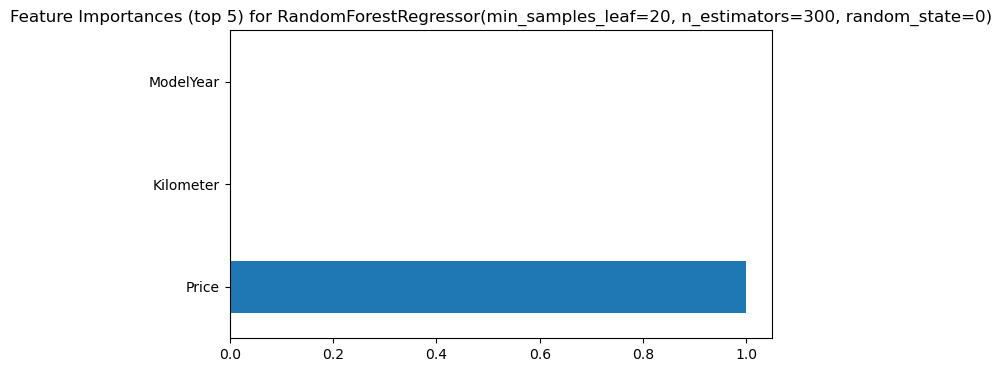

In [105]:

# Evaluation matrices for RandomForest
result = evaluate_model(rf_model, y_test,y_pred_rf)
score['Random forest tuned'] = result

Which hyperparameter optimization technique have i used and why?
GridSearchCV is used to find the best hyperparameters for a machine learning model by searching over a specified parameter grid. It helps to ensure that a model is not overfitting or underfitting by evaluating the model's performance using cross-validation techniques. GridSearchCV can save time and resources compared to manually tuning the parameters of a model.

To reduce time and effort we have used GridSearchCV.

# Have i seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [106]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139


## ML Model - 6 : Gradient Boosting Regressor

In [107]:
# Import Gradient Boosting Regressor class
gb = GradientBoostingRegressor(random_state=0)

# Fit the Gradient Boosting model to the training data
gb.fit(X_train,y_train)

# Predict on the model
y_pred_gb1 = gb.predict(X_test)

 Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MSE : 0.0007622816949275498
RMSE : 0.027609449377478536
MAE : 0.014627379220075787
Train R2 : 0.9999699659838786
Test R2 : 0.9999333031582964
Adjusted R2 :  0.9999326699604322


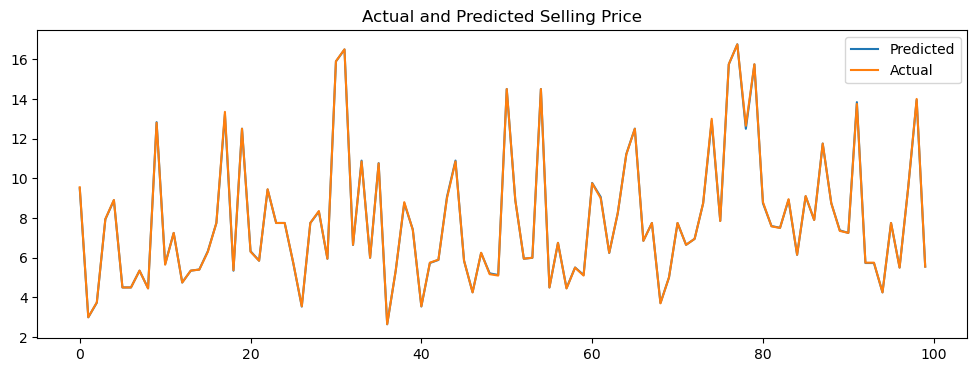

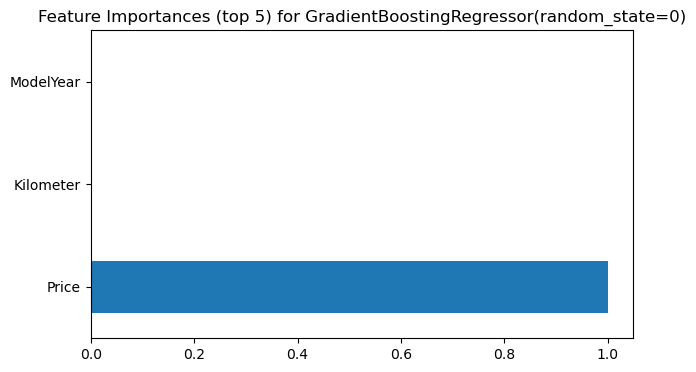

In [108]:
# Visualizing evaluation Metric Score chart
result = evaluate_model(gb, y_test,y_pred_gb1)
score['Gradient Boosting Regressor'] = result

In [109]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933


Using Gradient Boosting Regressor i have got accuracy around 99% and 99% on train and test data respectively, which is overfitting.
So, lets tune it.

# Cross- Validation & Hyperparameter Tuning

In [110]:
# Gradient Boosting Model
gb_model = GradientBoostingRegressor(random_state=0)
gb_params = {'n_estimators':[300],
             'min_samples_leaf':np.arange(20,24),
             'max_depth':np.arange(14,17)
             }
     

In [111]:
# Perform the randomized search
random_search = RandomizedSearchCV(gb_model, param_distributions=gb_params, cv=6, n_iter=20, scoring='neg_root_mean_squared_error', n_jobs=-1)
random_search.fit(X_train, y_train)

gb_best_params = random_search.best_params_
     

In [112]:
# Best parameters for Gradient Boosting Model
gb_best_params
     

{'n_estimators': 300, 'min_samples_leaf': 22, 'max_depth': 14}

In [113]:
# Building Gradient Boosting Model with best parameters
gb_model = GradientBoostingRegressor(n_estimators=gb_best_params['n_estimators'],
                                     min_samples_leaf=gb_best_params['min_samples_leaf'],
                                     max_depth = gb_best_params['max_depth'],
                                     random_state=0)

In [114]:
# Fitting model
gb_model.fit(X_train,y_train)

GradientBoostingRegressor(max_depth=14, min_samples_leaf=22, n_estimators=300,
                          random_state=0)

In [115]:
# Predict on the Model
y_pred_gb = gb_model.predict(X_test)

MSE : 0.012092159548013936
RMSE : 0.10996435580684287
MAE : 0.04344680221172788
Train R2 : 0.9994656284755729
Test R2 : 0.998941980560999
Adjusted R2 :  0.9989319360726541


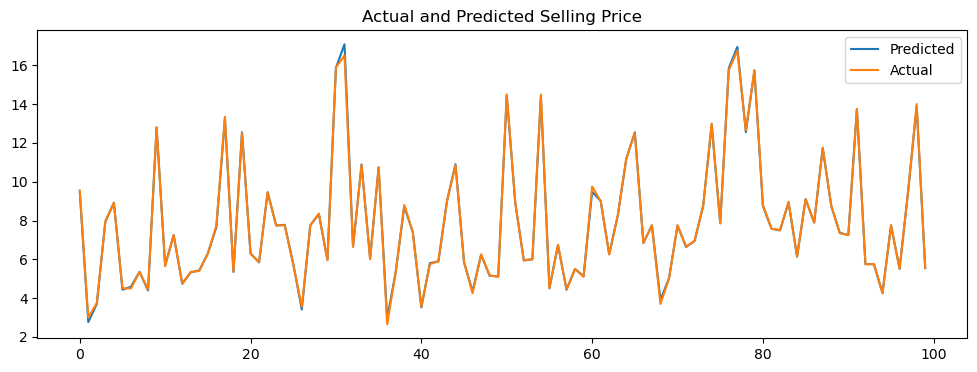

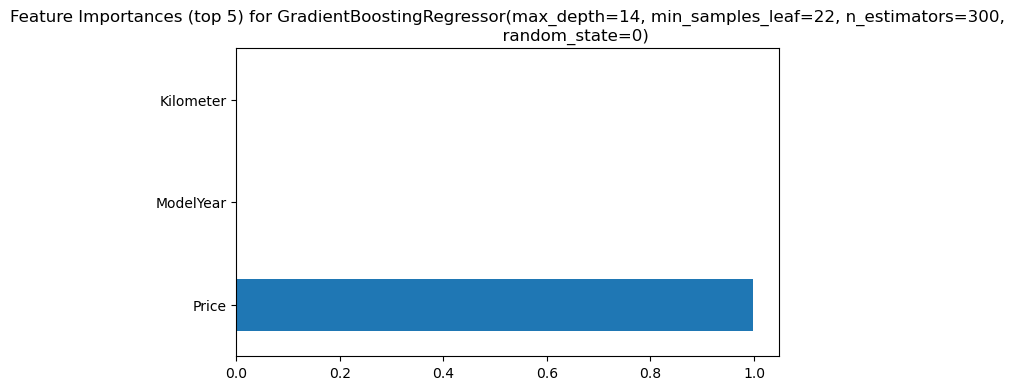

In [116]:
# Evaluation matrices for GradientBoosting
result = evaluate_model(gb_model, y_test,y_pred_gb)
score['Gradient Boosting Regressor Tuned'] = result

Which hyperparameter optimization technique have i used and why?
Randomized search cross-validation (CV) is used to efficiently explore the hyperparameter space of a machine learning model. It works by randomly sampling from the search space of hyperparameters, rather than exhaustively trying every possible combination. This allows for a more efficient search while still providing a good chance of finding good hyperparameter values. Additionally, by using cross-validation to evaluate the performance of each set of hyperparameters, one can ensure that the model is not overfitting to the training data.

Because of its randomly sampling technique and to save the time i have decided to use Randomized search CV

Have i seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [117]:
# Updated Evaluation Metric Score chart
score
     

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor,Gradient Boosting Regressor Tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762,0.012092
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609,0.109964
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627,0.043447
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970,0.999466
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933,0.998942
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933,0.998932


After using the Randomised search CV, it gave accuracy 99% on train data & 99% on test data which is comparatively less than the untuned model.

## ML Model - 7 : Extreme Gradient Boosting Regressor

In [118]:
# Import Extreme Gradient Boosting Regressor class
xgb_model = xgb.XGBRegressor(random_state=0,
                             objective='reg:squarederror')

# Fit the Extreme Gradient Boosting model to the training data
xgb_model.fit(X_train,y_train)

# Predict on the model
y_pred_xgb1 = xgb_model.predict(X_test)

Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MSE : 0.004880434519031476
RMSE : 0.06986010677798507
MAE : 0.033822525441646475
Train R2 : 0.9999729509642087
Test R2 : 0.9995729799485854
Adjusted R2 :  0.9995689259607555


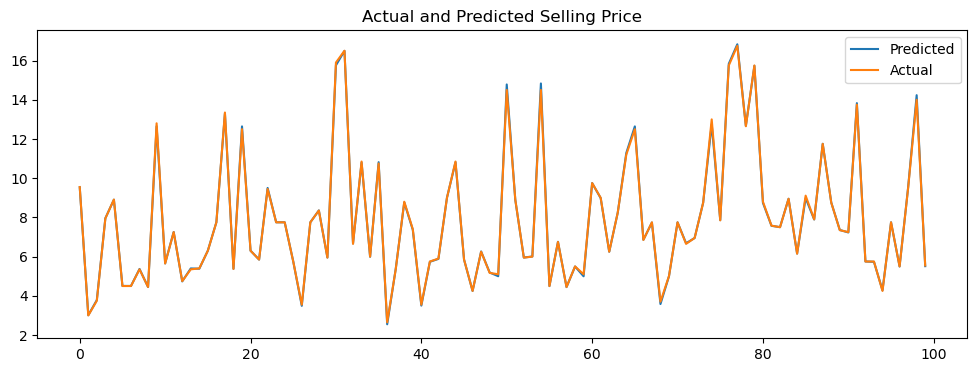

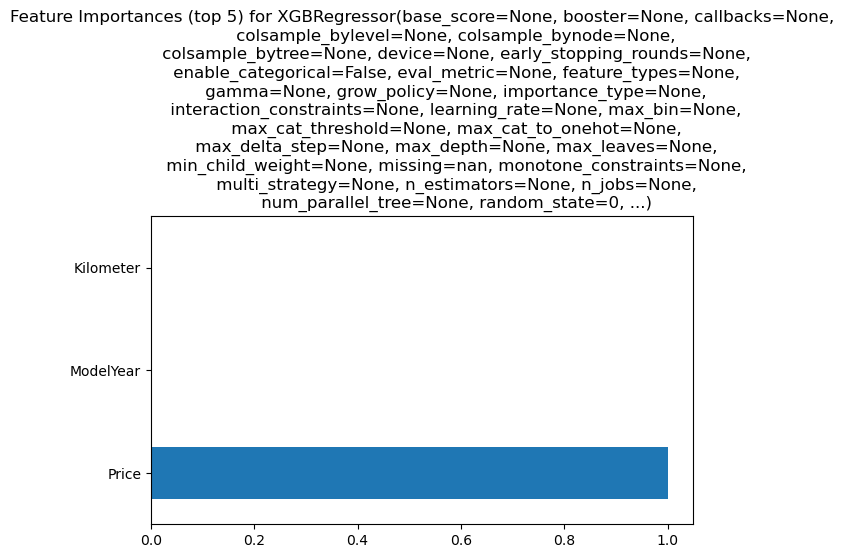

In [119]:
# Visualizing evaluation Metric Score chart
result = evaluate_model(xgb_model, y_test,y_pred_xgb1)
score['Extreme Gradient Boosting Regressor'] = result
     

In [120]:
# Updated Evaluation Metric Score chart
score
     

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor,Gradient Boosting Regressor Tuned,Extreme Gradient Boosting Regressor
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762,0.012092,0.004880
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609,0.109964,0.069860
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627,0.043447,0.033823
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970,0.999466,0.999973
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933,0.998942,0.999573
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933,0.998932,0.999569


Using Extreme Gradient Boosting Regressor i have got accuracy around 99% and 99% on train and test data respectively. It is overfitting the model's training accuracy is almost 100%.

So, lets tune it.

## Cross- Validation & Hyperparameter Tuning

In [121]:
# XG boost model
xgb_model = xgb.XGBRegressor(random_state=0,
                             objective='reg:squarederror')
xgb_params = {'n_estimators':[500],
             'min_samples_leaf':np.arange(20,22)}

In [122]:
# Perform the randomized search
xgb_search = RandomizedSearchCV(xgb_model,xgb_params,cv=6,scoring='neg_root_mean_squared_error',n_iter=100, n_jobs=-1)
xgb_search.fit(X_train,y_train)
xgb_best_params = xgb_search.best_params_
     

In [123]:

# Best parameters for XG boost Model
xgb_best_params

{'n_estimators': 500, 'min_samples_leaf': 20}

In [124]:
# Building a XG boost model with best parameters
xgb_model = xgb.XGBRegressor(n_estimators=xgb_best_params['n_estimators'],
                             min_samples_leaf=xgb_best_params['min_samples_leaf'],
                             random_state=0)
     

In [125]:
# Fitting model
xgb_model.fit(X_train,y_train)
     


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, min_samples_leaf=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [126]:
# Predict on the model
y_pred_xgb = xgb_model.predict(X_test)
     


MSE : 0.0048804407803082
RMSE : 0.06986015159093344
MAE : 0.03382252097129811
Train R2 : 0.999972950947686
Test R2 : 0.9995729794007467
Adjusted R2 :  0.9995689254077158


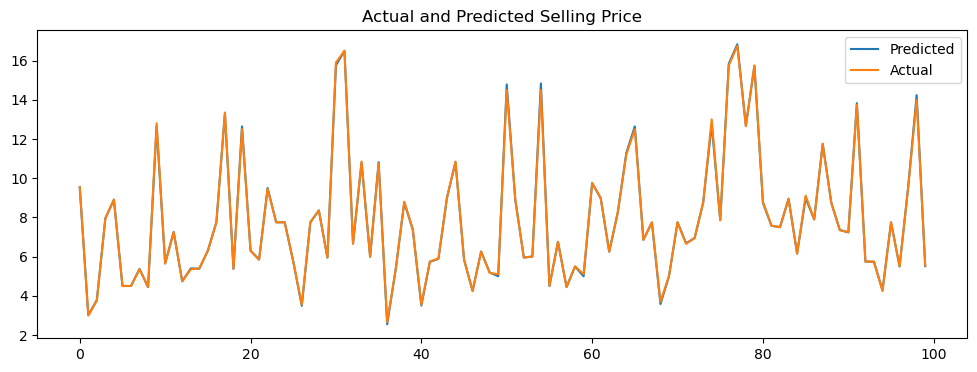

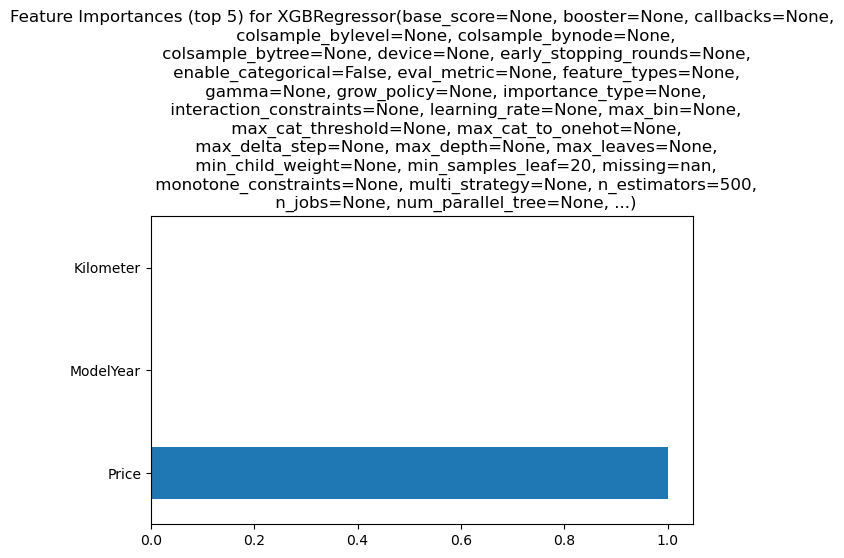

In [127]:
# Evaluation matrices for XGBRegressor
result = evaluate_model(xgb_model, y_test,y_pred_xgb)
score['Extreme Gradient Boosting Regressor Tuned'] = result

Which hyperparameter optimization technique have you used and why?
Randomized search cross-validation (CV) is used to efficiently explore the hyperparameter space of a machine learning model. It works by randomly sampling from the search space of hyperparameters, rather than exhaustively trying every possible combination. This allows for a more efficient search while still providing a good chance of finding good hyperparameter values. Additionally, by using cross-validation to evaluate the performance of each set of hyperparameters, one can ensure that the model is not overfitting to the training data.

Because of its randomly sampling technique and to save the time i have decided to use Randomized search CV.

Have i seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [128]:
# Updated Evaluation Metric Score chart
score
     

,Linear regression,Linear regression tuned,Lasso regression,Lasso with alpha = 1e-05,Ridge,Ridge with alpha = 5,Decision tree,Decision tree tuned,Random forest,Random forest tuned,Gradient Boosting Regressor,Gradient Boosting Regressor Tuned,Extreme Gradient Boosting Regressor,Extreme Gradient Boosting Regressor Tuned
MSE,0.871905,0.871905,11.958381,0.871696,0.862146,0.824893,0.001704,0.086998,0.000762,0.077679,0.000762,0.012092,0.004880,0.004880
RMSE,0.933759,0.933759,3.458089,0.933647,0.928518,0.908236,0.041284,0.294953,0.027610,0.278710,0.027609,0.109964,0.069860,0.069860
MAE,0.553466,0.553466,2.536224,0.553429,0.551854,0.545613,0.013563,0.182795,0.011742,0.138181,0.014627,0.043447,0.033823,0.033823
Train R2,0.914701,0.914701,-0.032728,0.914720,0.915610,0.919092,1.000000,0.993178,0.999988,0.993592,0.999970,0.999466,0.999973,0.999973
Test R2,0.923712,0.923712,-0.046314,0.923730,0.924565,0.927825,0.999851,0.992388,0.999933,0.993203,0.999933,0.998942,0.999573,0.999573
Adjusted R2,0.922987,0.922987,-0.056248,0.923006,0.923849,0.927140,0.999849,0.992316,0.999933,0.993139,0.999933,0.998932,0.999569,0.999569


After tuning the model i have got the same accuracy on train and test data. Both are overfitted model.

## Plot R2 scores for each model

In [129]:
score.columns

Index(['Linear regression', 'Linear regression tuned', 'Lasso regression',
       'Lasso with alpha = 1e-05', 'Ridge', 'Ridge with alpha = 5',
       'Decision tree', 'Decision tree tuned', 'Random forest',
       'Random forest tuned', 'Gradient Boosting Regressor',
       'Gradient Boosting Regressor Tuned',
       'Extreme Gradient Boosting Regressor',
       'Extreme Gradient Boosting Regressor Tuned'],
      dtype='object')

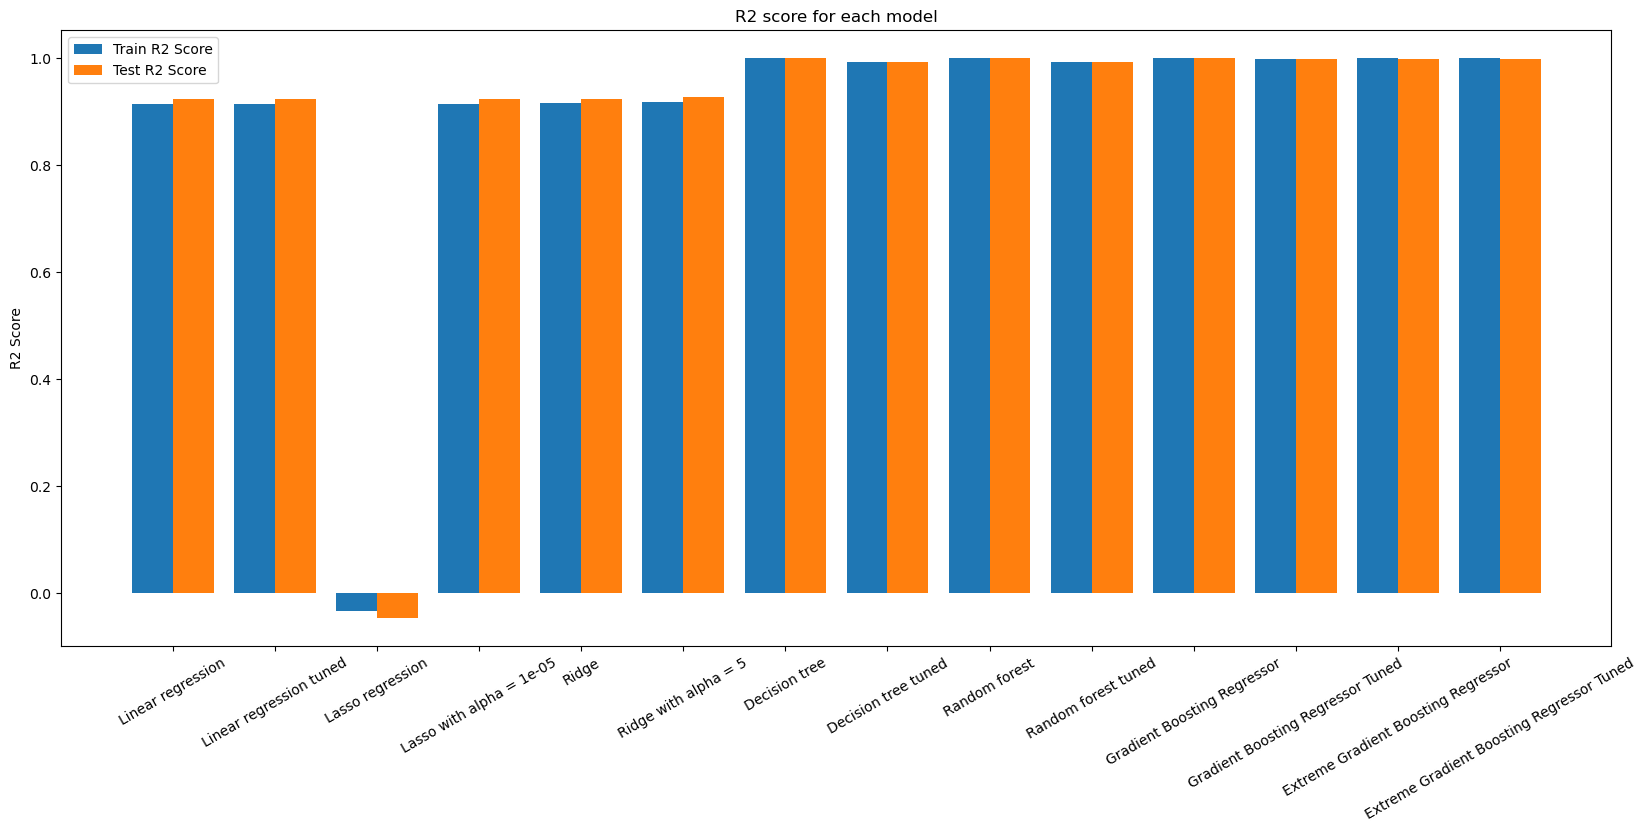

In [130]:
# R2 Scores plot

models = list(score.columns)
train = score.iloc[-3,:]
test = score.iloc[-2,:]

X_axis = np.arange(len(models))

plt.figure(figsize=(20,8))
plt.bar(X_axis - 0.2, train, 0.4, label = 'Train R2 Score')
plt.bar(X_axis + 0.2, test, 0.4, label = 'Test R2 Score')


plt.xticks(X_axis,models, rotation=30)
plt.ylabel("R2 Score")
plt.title("R2 score for each model")
plt.legend()
plt.show()

Which Evaluation metrics did i consider for a positive business impact and why?
On the basis of all the model i have decided to select R2 score Evaluation matrics which shows the accuracy of the model which is very good indicator to check the feasibility of the model.

2. Which ML model did i choose from the above created models as the final prediction model and why?
I have ran a several models like linear regression, decision tree, random forest, gradient boosting, and xtreame gradient boosting but amongst them i have selected random forest model as i achieved 99% training accuracy and 99% testing accuracy. Some models were overfitted so i did not consider them.

